In [2]:
import pandas as pd

df = pd.read_csv("zomato.csv")

print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Zomato Restaurant Data Analysis

## Data Understanding


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [4]:
df.isnull().sum()


url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [6]:
df['rate'].unique()[:20]

<StringArray>
['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5', '3.9/5',
 '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5', '4.3/5',   'NEW',
 '2.9/5', '3.5/5',     nan, '2.6/5']
Length: 20, dtype: str

In [7]:
df['rate'] = df['rate'].replace('NEW', pd.NA)

In [8]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [9]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [10]:
df['rate'].head(20)

0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
9     4.2
10    4.1
11    4.2
12    4.2
13    4.0
14    3.8
15    3.8
16    3.9
17    3.8
18    3.9
19    3.1
Name: rate, dtype: float64

In [11]:
df['rate'].dtype

dtype('float64')

In [12]:
df['rate'].replace('NEW', pd.NA)

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64

In [13]:
df['rate'].mean()

np.float64(3.700448817952718)

## EDA 1: Top Rated Locations

In [14]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.142505
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.005821
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.863636
MG Road                  3.855857
Name: rate, dtype: float64

### Business Insight

Lavelle Road recorded the highest average restaurant rating (4.14), suggesting strong customer satisfaction and service quality in this area.

Koramangala (3rd Block and 5th Block) and Church Street also emerged as highly rated food destinations.

These locations could be prioritized for marketing campaigns, premium restaurant partnerships, and recommendation strategies.

In [15]:
df['location'].value_counts().head(10)

location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64

## EDA 2: Top 10 Locations by Number of Restaurants

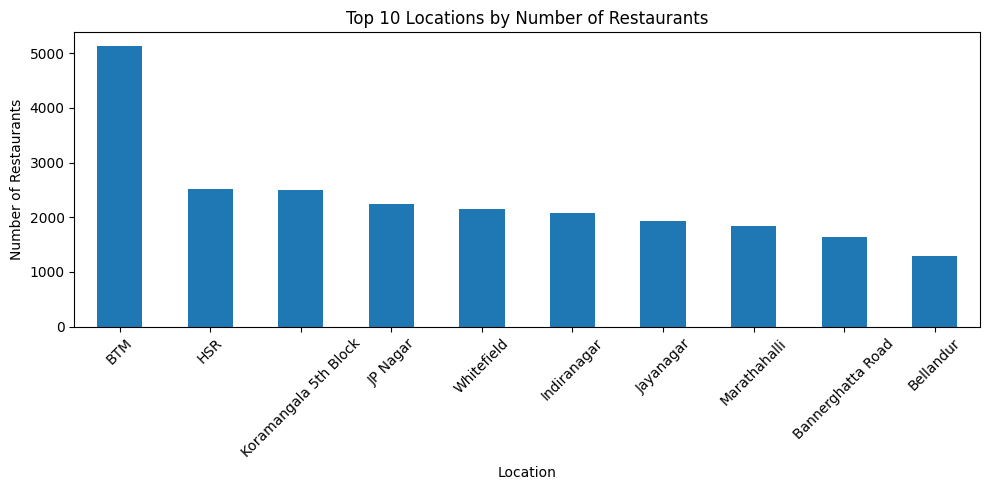

In [16]:
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')

plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Insight

BTM contains the highest concentration of restaurants (5,124), making it the most competitive food market in Bangalore.

HSR and Koramangala also show high restaurant density, indicating strong food demand and business activity in these locations.

Online Orders vs Ratings

In [17]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.65907
Yes    3.72244
Name: rate, dtype: float64

### Business Insight

Restaurants offering online ordering achieved a slightly higher average rating (3.72) compared to restaurants without online ordering (3.66).

This suggests a positive association between online ordering availability and customer satisfaction. However, further analysis is required to determine whether online ordering directly influences ratings or if other factors contribute to this relationship.

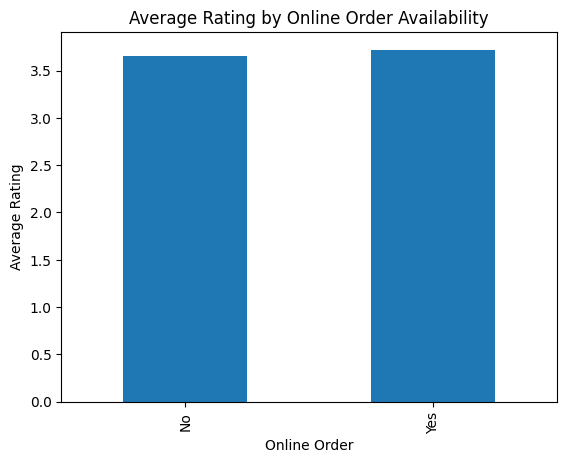

In [18]:
online_rating = df.groupby('online_order')['rate'].mean()

online_rating.plot(kind='bar')

plt.title('Average Rating by Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')

plt.show()

# EDA 3: Table Booking vs Ratings

In [19]:
df.groupby('book_table')['rate'].mean()


book_table
No     3.621470
Yes    4.143464
Name: rate, dtype: float64

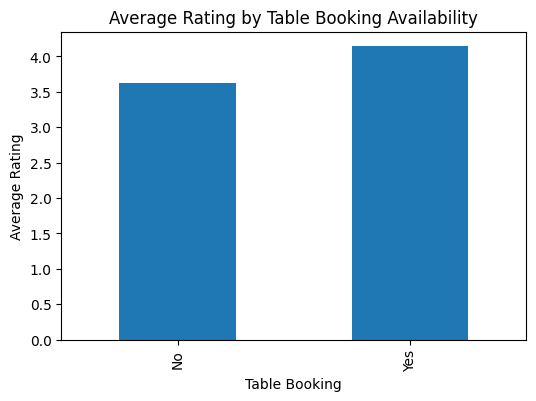

In [20]:
import matplotlib.pyplot as plt

df.groupby('book_table')['rate'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Rating by Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')

plt.show()

## Business Insight

Restaurants that offer table booking have a significantly higher average rating (4.14) compared to restaurants without table booking (3.62).

This suggests that table booking is strongly associated with premium dining experiences and higher customer satisfaction.

Restaurants looking to improve customer experience may benefit from implementing reservation systems.

Which restaurant types are most common?

In [21]:
df['rest_type'].value_counts().head(10)

rest_type
Quick Bites           19132
Casual Dining         10330
Cafe                   3732
Delivery               2604
Dessert Parlor         2263
Takeaway, Delivery     2037
Casual Dining, Bar     1154
Bakery                 1141
Beverage Shop           867
Bar                     697
Name: count, dtype: int64

## Business Insight

Quick Bites is the most common restaurant type in Bangalore with over 19,000 outlets.

This indicates strong demand for fast, affordable, and convenient food options.

Any new food business entering the market should consider the Quick Bites model due to its popularity.


Which restaurant type has the highest rating?

In [22]:
df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.478571
Pub, Microbrewery              4.452632
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369421
Name: rate, dtype: float64

## Business Insight

Premium restaurant formats such as Pubs, Cafes, and Microbreweries receive the highest customer ratings in Bangalore.

This suggests that customers value overall dining experience, ambience, and service quality in addition to food quality.

Restaurants targeting premium customers may achieve higher satisfaction ratings.

In [23]:
df['rest_type'].value_counts().loc[
    ['Pub, Cafe',
     'Bar, Pub',
     'Microbrewery',
     'Pub, Microbrewery',
     'Microbrewery, Bar']
]

rest_type
Pub, Cafe            40
Bar, Pub              5
Microbrewery         30
Pub, Microbrewery    84
Microbrewery, Bar    13
Name: count, dtype: int64

In [24]:
df.groupby('rest_type').agg({
    'rate':'mean'
}).sort_values('rate', ascending=False).head(10)

,rate
rest_type,
"Pub, Cafe",4.657500
"Bar, Pub",4.600000
Microbrewery,4.478571
"Pub, Microbrewery",4.452632
"Microbrewery, Bar",4.446154
"Microbrewery, Pub",4.438095
"Casual Dining, Irani Cafee",4.406667
"Cafe, Lounge",4.400000
"Fine Dining, Lounge",4.400000


Most Popular Cuisines

In [25]:
df['cuisines'].value_counts().head(10)

cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Name: count, dtype: int64

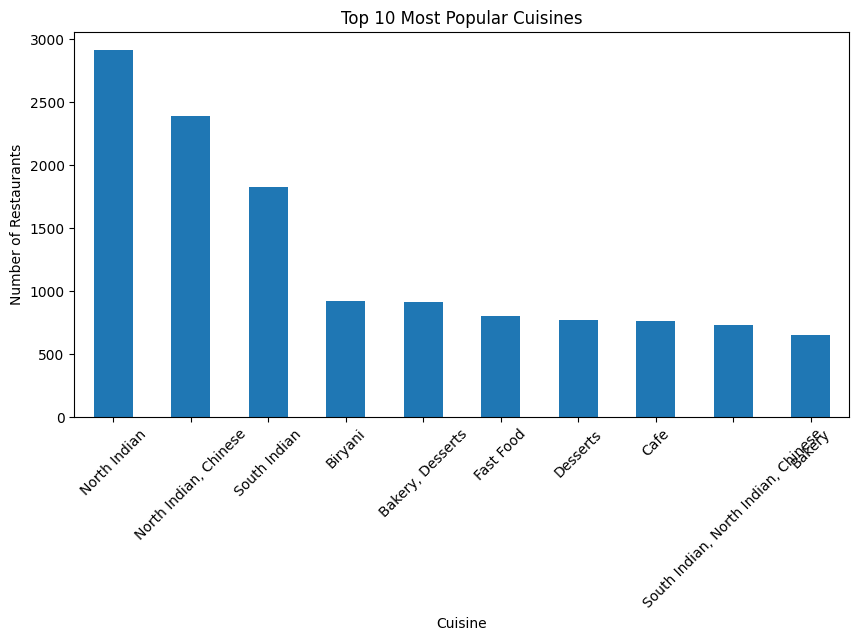

In [26]:
plt.figure(figsize=(10,5))
df['cuisines'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

In [27]:
df['cuisines'].value_counts().head(10)

cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Name: count, dtype: int64

## Business Insight

North Indian cuisine is the most common cuisine in Bangalore, followed by North Indian-Chinese combinations and South Indian cuisine.

This indicates strong customer demand for Indian food, while Chinese cuisine is often offered as a complementary option.

Restaurant owners entering the market should consider these cuisines due to their widespread popularity and customer acceptance.

Customer Budget Analysis

In [28]:
df['approx_cost(for two people)'].head()

0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: str

In [29]:
df['approx_cost(for two people)'].unique()[:20]

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000']
Length: 20, dtype: str

In [30]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .str.replace(',', '', regex=False)
)

In [31]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [32]:
df['approx_cost(for two people)'].dtype

dtype('float64')

In [33]:
df['approx_cost(for two people)'].mean()

np.float64(555.4315664479959)

Cheapest and Most Expensive Restaurants



In [34]:
df['approx_cost(for two people)'].describe()

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

Which Locations Are Most Expensive?

In [35]:
df.groupby('location')['approx_cost(for two people)'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

location
Sankey Road         2505.555556
Race Course Road    1309.352518
Lavelle Road        1307.934990
MG Road             1155.704698
Infantry Road       1062.251656
Residency Road       966.320475
Langford Town        883.333333
St. Marks Road       871.306818
Cunningham Road      864.969450
Church Street        834.885764
Name: approx_cost(for two people), dtype: float64

In [36]:
df['location'].value_counts().loc[
    ['Sankey Road',
     'Race Course Road',
     'Lavelle Road',
     'MG Road',
     'Infantry Road']
]

location
Sankey Road          27
Race Course Road    139
Lavelle Road        529
MG Road             918
Infantry Road       151
Name: count, dtype: int64

In [37]:
df.groupby('approx_cost(for two people)')['rate'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

approx_cost(for two people)
120.0     4.400000
3200.0    4.400000
3500.0    4.328000
1250.0    4.325000
1650.0    4.300000
3400.0    4.300000
5000.0    4.300000
4500.0    4.300000
6000.0    4.300000
2700.0    4.266667
Name: rate, dtype: float64

In [38]:
df['approx_cost(for two people)'].value_counts().loc[
    [120, 3200, 3500, 1250]
]

approx_cost(for two people)
120.0     24
3200.0     2
3500.0    25
1250.0     9
Name: count, dtype: int64

Which Restaurant Types Have The Highest Ratings?

In [39]:
df.groupby('rest_type')['rate'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.478571
Pub, Microbrewery              4.452632
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369421
Name: rate, dtype: float64

In [40]:
top_types = [
    'Pub, Cafe',
    'Bar, Pub',
    'Microbrewery'
]

df['rest_type'].value_counts().loc[top_types]

rest_type
Pub, Cafe       40
Bar, Pub         5
Microbrewery    30
Name: count, dtype: int64

Microbreweries and Pub-Cafes consistently achieve high ratings with a reasonable number of restaurants, suggesting strong customer satisfaction.

Do restaurants with more votes get better ratings?

In [41]:
df[['votes', 'rate']].corr()

,votes,rate
votes,1.00000,0.43404
rate,0.43404,1.00000


Restaurants with more votes tend to have better ratings.

There is a moderate positive relationship (0.43) between the number of votes and restaurant ratings, suggesting that popular restaurants tend to receive better customer ratings.

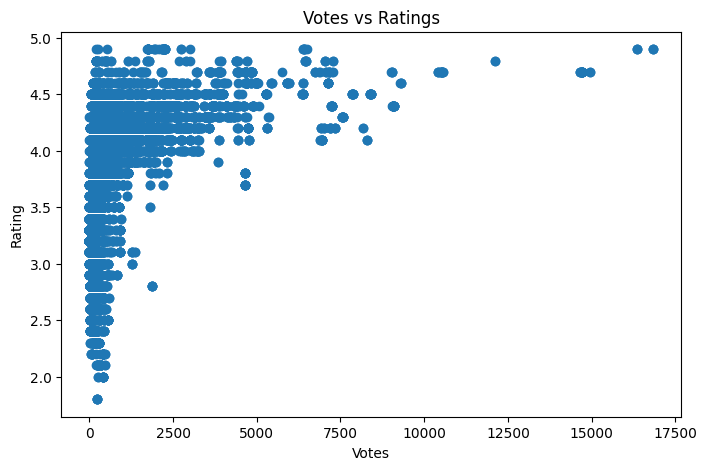

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(df['votes'], df['rate'])

plt.title('Votes vs Ratings')
plt.xlabel('Votes')
plt.ylabel('Rating')

plt.show()

Which Restaurants Get the Most Votes?

In [44]:
Which Restaurants Get the Most Votes?

Object `Votes` not found.


In [45]:
top_voted = df.sort_values('votes', ascending=False)

top_voted[['name', 'location', 'votes', 'rate']].head(10)

,name,location,votes,rate
49170,Byg Brewski Brewing Company,Sarjapur Road,16832,4.9
49627,Byg Brewski Brewing Company,Sarjapur Road,16832,4.9
50059,Byg Brewski Brewing Company,Sarjapur Road,16832,4.9
3921,Byg Brewski Brewing Company,Sarjapur Road,16345,4.9
4801,Byg Brewski Brewing Company,Sarjapur Road,16345,4.9
4944,Byg Brewski Brewing Company,Sarjapur Road,16345,4.9
18643,Toit,Indiranagar,14956,4.7
19268,Toit,Indiranagar,14956,4.7
36668,Truffles,Koramangala 5th Block,14726,4.7
34779,Truffles,Koramangala 5th Block,14723,4.7


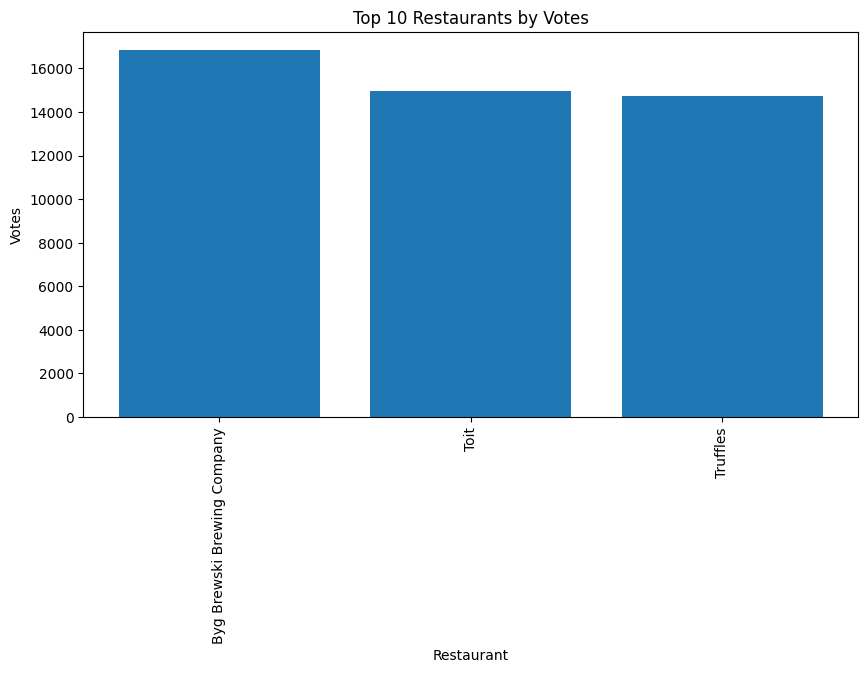

In [46]:
top10 = df.sort_values('votes', ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10['name'], top10['votes'])

plt.title('Top 10 Restaurants by Votes')
plt.xlabel('Restaurant')
plt.ylabel('Votes')

plt.xticks(rotation=90)

plt.show()

 Which Cuisine Gets the Best Ratings?
Run

In [47]:
df.groupby('cuisines')['rate'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

cuisines
Healthy Food, Salad, Mediterranean                                       4.900000
Asian, Chinese, Thai, Momos                                              4.900000
Continental, North Indian, Italian, South Indian, Finger Food            4.900000
Continental, North Indian, Chinese, European, BBQ, Finger Food, Asian    4.800000
Asian, Mediterranean, North Indian, BBQ                                  4.800000
North Indian, European, Mediterranean, BBQ                               4.800000
European, Mediterranean, North Indian, BBQ                               4.789474
American, Tex-Mex, Burger, BBQ, Mexican                                  4.750000
Chinese, American, Continental, Italian, North Indian                    4.700000
Asian, Burmese                                                           4.700000
Name: rate, dtype: float64

In [48]:
top_cuisines = [
'Healthy Food, Salad, Mediterranean',
'Asian, Chinese, Thai, Momos',
'Continental, North Indian, Italian, South Indian, Finger Food',
'Asian, Mediterranean, North Indian, BBQ',
'European, Mediterranean, North Indian, BBQ'
]

df['cuisines'].value_counts().loc[top_cuisines]

cuisines
Healthy Food, Salad, Mediterranean                                1
Asian, Chinese, Thai, Momos                                      19
Continental, North Indian, Italian, South Indian, Finger Food     6
Asian, Mediterranean, North Indian, BBQ                           6
European, Mediterranean, North Indian, BBQ                       19
Name: count, dtype: int64

The more trustworthy cuisines here are:

Asian, Chinese, Thai, Momos
European, Mediterranean, North Indian, BBQ

Next EDA: Which Cuisine Gets the Most Votes?

In [49]:
df.groupby('cuisines')['votes'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

cuisines
Continental, North Indian, Italian, South Indian, Finger Food    16588.500000
Italian, American, Pizza                                         14956.000000
North Indian, European, Mediterranean                            10498.846154
American, Continental, North Indian, Mediterranean                9164.500000
American, Continental, Salad                                      8379.200000
American, Continental, North Indian, Salad                        7860.900000
North Indian, European, Mediterranean, BBQ                        7127.400000
Cafe, American, Burger                                            7124.875000
Cafe, American, Burger, Steak                                     7001.372093
Continental, European, BBQ, Chinese, Asian                        6986.600000
Name: votes, dtype: float64

EDA 7: Online Order vs Votes

In [50]:
df.groupby('online_order')['votes'].mean()

online_order
No     250.31594
Yes    307.02319
Name: votes, dtype: float64

This suggests:

Online ordering is associated with more visibility.

 More customers interact with these restaurants.

 More interactions lead to more reviews/votes.

8) Book Table vs Votes

In [51]:
df.groupby('book_table')['votes'].mean()

book_table
No      160.690664
Yes    1147.129788
Name: votes, dtype: float64

Restaurants offering table booking receive significantly higher customer engagement (1147 average votes vs 160), indicating that premium dining experiences attract more customer interaction and reviews.

In [52]:
df[['name','rate','votes']] \
.sort_values(['rate','votes'], ascending=False) \
.head(10)

,name,rate,votes
49170,Byg Brewski Brewing Company,4.9,16832
49627,Byg Brewski Brewing Company,4.9,16832
50059,Byg Brewski Brewing Company,4.9,16832
3921,Byg Brewski Brewing Company,4.9,16345
4801,Byg Brewski Brewing Company,4.9,16345
4944,Byg Brewski Brewing Company,4.9,16345
37099,AB's - Absolute Barbecues,4.9,6490
21279,AB's - Absolute Barbecues,4.9,6452
19393,AB's - Absolute Barbecues,4.9,6404
21770,AB's - Absolute Barbecues,4.9,6404


In [53]:
top_restaurants = df.groupby('name').agg({
    'rate':'mean',
    'votes':'sum'
})

top_restaurants.sort_values(
    ['rate','votes'],
    ascending=False
).head(10)

,rate,votes
name,,
Byg Brewski Brewing Company,4.900000,99531
Asia Kitchen By Mainland China,4.900000,42273
SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Spa Cuisine,4.900000,246
Punjab Grill,4.871429,9660
Belgian Waffle Factory,4.844828,24882
Flechazo,4.800000,29956
The Pizza Bakery,4.800000,10523
O.G. Variar & Sons,4.800000,2317
AB's - Absolute Barbecues,4.789474,86418


Byg Brewski Brewing Company
Rating = 4.9
Votes = 99,531

In [55]:
df[['approx_cost(for two people)','rate']].corr()

,approx_cost(for two people),rate
approx_cost(for two people),1.000000,0.385183
rate,0.385183,1.000000


Restaurant cost and rating show a moderate positive correlation (0.385), suggesting that premium restaurants generally receive better customer ratings, although price alone does not guarantee quality.

Final Business Conclusion 
# Final Business Insights

1. BTM has the highest concentration of restaurants, making it the most competitive food market in Bangalore.

2. Restaurants offering online ordering receive higher average ratings and customer engagement.

3. Restaurants with table booking significantly outperform others in both ratings and votes.

4. Microbreweries and premium dining formats receive the highest customer ratings.

5. North Indian cuisine dominates Bangalore's restaurant market.

6. Certain premium cuisine combinations receive exceptionally high customer engagement.

7. Byg Brewski Brewing Company emerged as the strongest restaurant brand with both high ratings and massive customer engagement.

8. Restaurant cost and ratings show a moderate positive relationship (correlation = 0.385), indicating that premium restaurants generally receive better ratings.